In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import pickle
import networkx as nx

In [4]:
with open("results_w1_delta.pkl", "rb") as f:
    data = pickle.load(f)

coef = data["matriz_coeficientes"]
sig = data["matriz_significancia"]
especies = data["especies"]

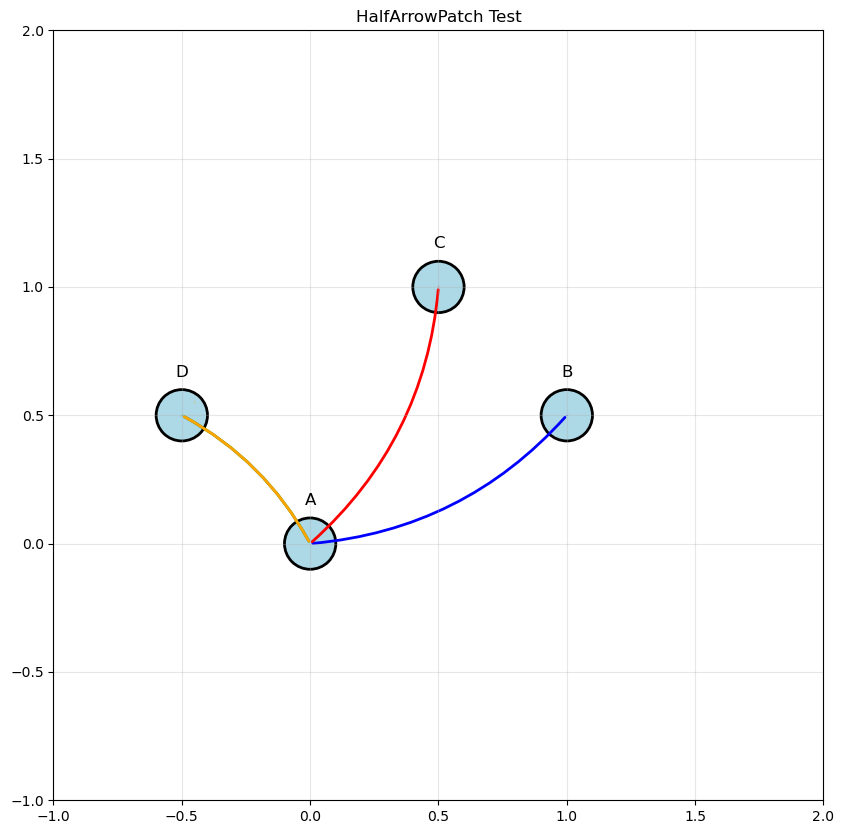

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *

class HalfArrowPatch(FancyArrowPatch):
    """
    A custom arrow patch that draws arrows with half arrowheads.
    Useful for drawing multiple parallel edges between nodes.
    """
    
    def __init__(self, posA, posB, marker='-|>', width=1, height=1, 
                 color='black', linewidth=1, curvature=0.3, 
                 arrow_linewidth=2, **kwargs):
        """
        Initialize a HalfArrowPatch.
        
        Parameters:
        -----------
        posA, posB : tuples
            Starting and ending positions (x, y)
        marker : str
            Arrow style ('-|>' for right half, '|\\' for left half, etc.)
        width, height : float
            Width and height of the arrowhead
        color : str or tuple
            Arrow color
        linewidth : float
            Width of the arrow shaft
        curvature : float
            Curvature of the arrow (0 = straight, >0 = curved)
        arrow_linewidth : float
            Width of the arrowhead lines
        **kwargs : additional arguments for FancyArrowPatch
        """
        # Store parameters
        self.marker = marker
        self.arrow_width = width
        self.arrow_height = height
        self.arrow_linewidth = arrow_linewidth
        self.curvature = curvature
        
        # Initialize the parent class
        super().__init__(posA, posB, 
                        connectionstyle=f"arc3,rad={curvature}",
                        arrowstyle='-',  # Start with no arrowhead, we'll draw it manually
                        color=color,
                        linewidth=linewidth,
                        **kwargs)
        
        self._color = color
        self._posA = np.array(posA)
        self._posB = np.array(posB)
        
    def draw(self, renderer):
        """Override draw method to add custom half arrowhead."""
        # Draw the curved line first
        super().draw(renderer)
        
        # Get the transformed points
        trans = self.get_transform()
        posA_trans = trans.transform(self._posA)
        posB_trans = trans.transform(self._posB)
        
        # Calculate the direction at the end of the curve
        # For curved arrows, we need the tangent at the endpoint
        if self.curvature != 0:
            # For curved arrows, calculate tangent at endpoint
            C, R = self._get_circle_center()
            if C is not None:
                # Vector from center to endpoint
                v = posB_trans - C
                # Tangent is perpendicular to radius
                tangent = np.array([-v[1], v[0]])
                tangent = tangent / np.linalg.norm(tangent)
            else:
                # Fallback to straight line direction
                tangent = posB_trans - posA_trans
                tangent = tangent / np.linalg.norm(tangent)
        else:
            # Straight line - direction is from start to end
            tangent = posB_trans - posA_trans
            tangent = tangent / np.linalg.norm(tangent)
        
        # Perpendicular vector (90 degrees rotation)
        perp = np.array([-tangent[1], tangent[0]])
        
        # Calculate arrowhead points based on marker style
        arrowhead_center = posB_trans
        
        if self.marker == '-|>' or self.marker == '|>':
            # Right half arrowhead (pointing to the right of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|\\' or self.marker == '<|':
            # Left half arrowhead (pointing to the left of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|<':
            # Half arrowhead on the other side (for bidirectional)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        else:
            # Default full arrowhead
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center
            ]
        
        # Create the arrowhead patch
        if len(points) >= 3:
            # Create path for the filled arrowhead
            verts = points
            codes = [Path.MOVETO] + [Path.LINETO] * (len(points)-2) + [Path.CLOSEPOLY]
            
            path = Path(verts, codes)
            patch = PathPatch(path, facecolor=self._color, 
                            edgecolor=self._color, 
                            linewidth=self.arrow_linewidth,
                            transform=transforms.IdentityTransform(),
                            zorder=self.zorder+1)
            
            # Draw the arrowhead
            patch.draw(renderer)
    
    def _get_circle_center(self):
        """Calculate the center of the circle for curved arrows."""
        try:
            A = self._posA
            B = self._posB
            rad = self.curvature
            
            # Calculate the center of the arc
            M = (A + B) / 2
            d = B - A
            L = np.linalg.norm(d)
            
            if L == 0:
                return None, None
                
            n = np.array([-d[1], d[0]]) / L
            h = rad * L / 2
            R = (L**2 / 4 + h**2) / (2 * h)
            C = M + n * (R - L**2 / (8 * h))
            
            return C, R
        except:
            return None, None


def test_half_arrow():
    """Test function to demonstrate HalfArrowPatch usage."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create some test positions
    pos = {
        'A': np.array([0, 0]),
        'B': np.array([1, 0.5]),
        'C': np.array([0.5, 1]),
        'D': np.array([-0.5, 0.5])
    }
    
    # Draw nodes
    for node, p in pos.items():
        circle = plt.Circle(p, 0.1, color='lightblue', ec='black', lw=2)
        ax.add_patch(circle)
        ax.text(p[0], p[1]+0.15, node, ha='center', fontsize=12)
    
    # Test different arrow styles
    # Right half arrow
    arrow1 = HalfArrowPatch(
        pos['A'], pos['B'],
        marker='-|>',
        width=0.2, height=0.3,
        color='blue',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow1)
    
    # Left half arrow
    arrow2 = HalfArrowPatch(
        pos['A'], pos['C'],
        marker='|\\',
        width=0.2, height=0.3,
        color='red',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow2)
    
    # Double arrows (parallel)
    arrow3 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='-|>',
        width=0.2, height=0.3,
        color='green',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    ax.add_patch(arrow3)
    
    arrow4 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='|\\',
        width=0.2, height=0.3,
        color='orange',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    # Adjust offset manually
    arrow4._posA = arrow4._posA + np.array([0.05, 0.05])
    arrow4._posB = arrow4._posB + np.array([0.05, 0.05])
    ax.add_patch(arrow4)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('HalfArrowPatch Test')
    
    plt.show()


if __name__ == "__main__":
    test_half_arrow()
    



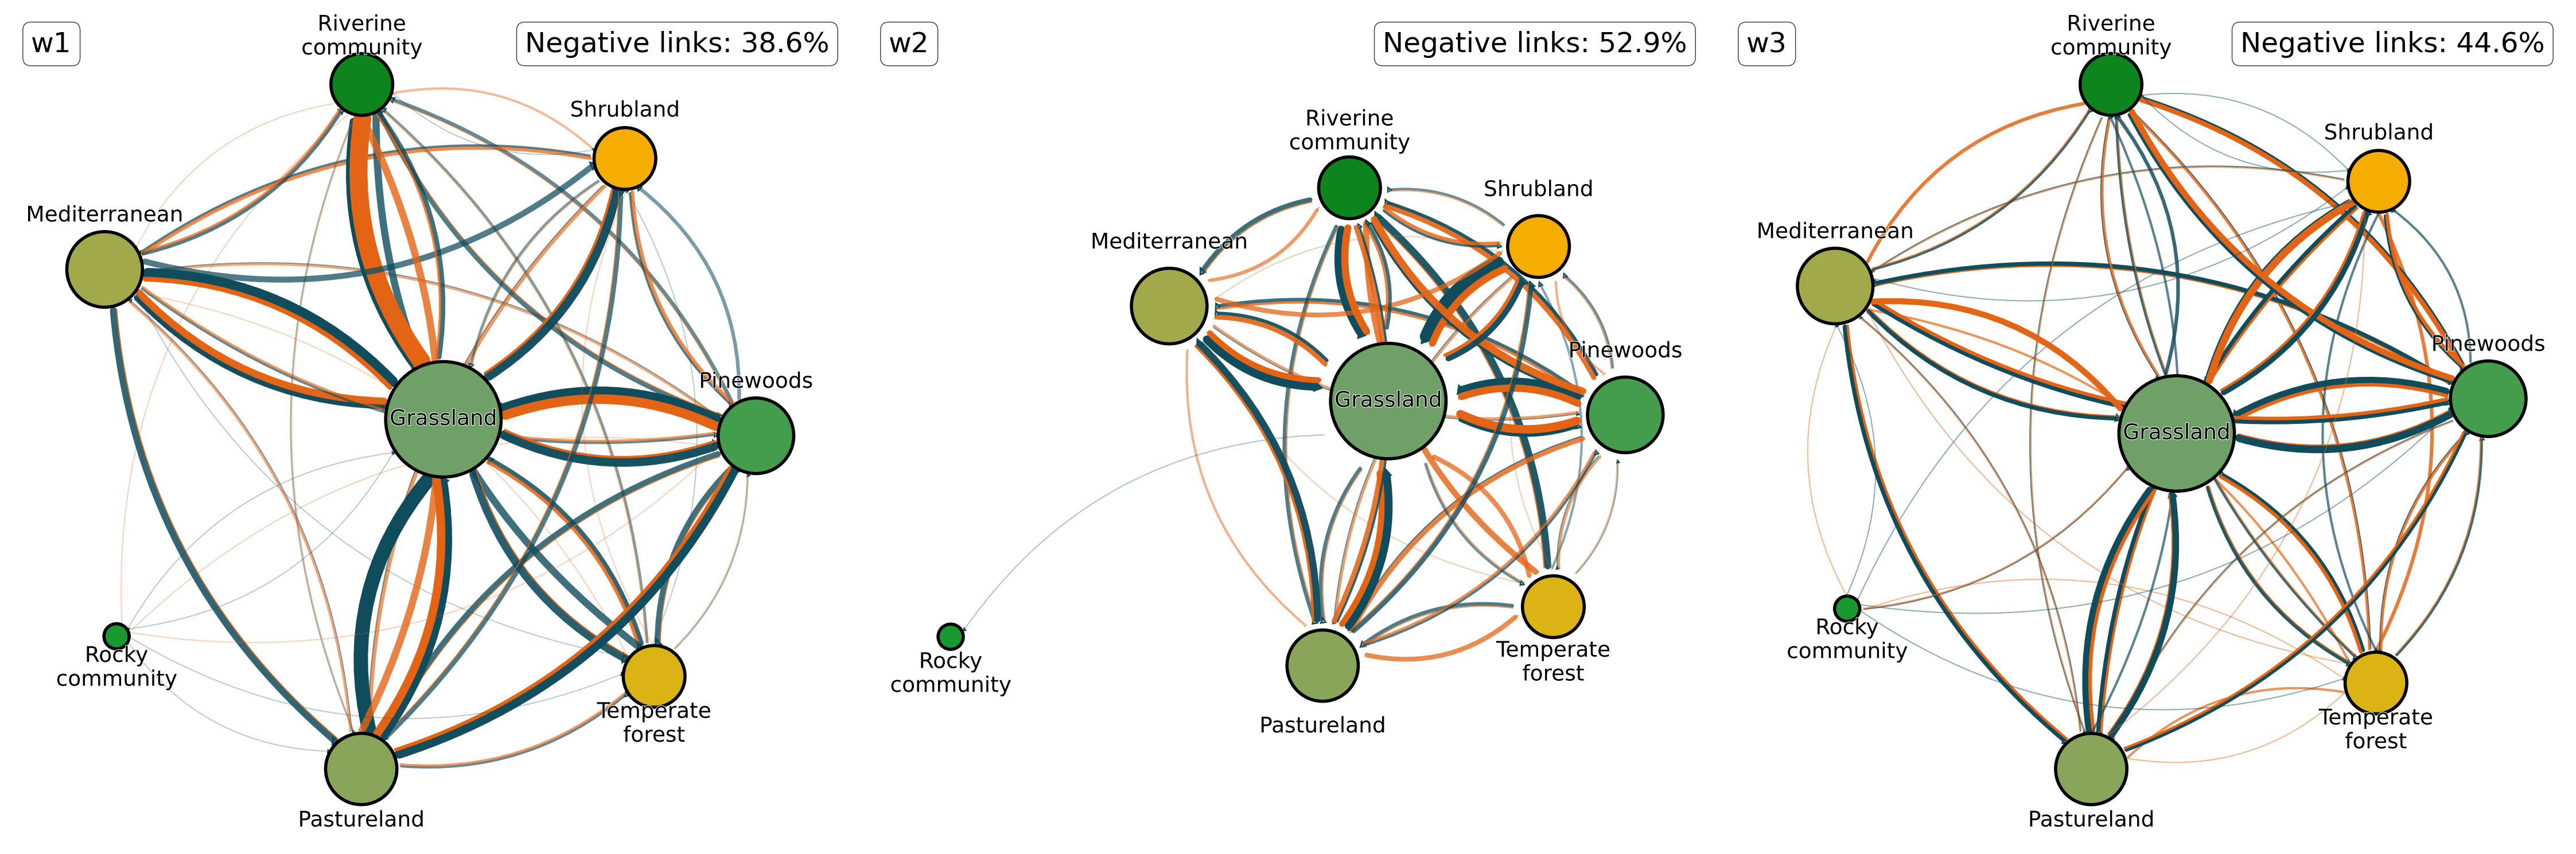

In [11]:
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

# Importar las funciones personalizadas
from lib.halfarrowpatch import *  # Asegúrate de que esta importación funciona

# =====================================================
# FUNCIONES AUXILIARES (copiadas de tu código)
# =====================================================

def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) / 2
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L / 2
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, 
                    offset=0.0, node_radius_u=0.05, node_radius_v=0.05, 
                    arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

def sequential_custom_generator():
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows
    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

# =====================================================
# CONFIG
# =====================================================

windows_names = ["w1", "w2", "w3"]

POS_COLOR = "#0F4C5C"  # Azul verdoso para positivas
NEG_COLOR = "#E36414"  # Naranja para negativas

# =====================================================
# COMUNIDADES
# =====================================================

groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# =====================================================
# MAPEO DE COMUNIDADES A ÍNDICES Y ETIQUETAS
# =====================================================

# Crear mapeo inverso de comunidad a índice numérico
community_to_index = {
    'grassland': 0,
    'mediterranean': 1,
    'pastureland': 2,
    'pinewoods': 3,
    'riverine community': 4,
    'rocky community': 5,
    'shrubland': 6,
    'temperate forest': 7
}

# Mapeo de índice a etiqueta (igual que en el original)
labels = {
    7: 'Temperate\nforest',
    3: 'Pinewoods',
    6: 'Shrubland',
    4: 'Riverine\ncommunity',
    1: 'Mediterranean',
    2: 'Pastureland',
    0: 'Grassland',
    5: 'Rocky\ncommunity'
}

# Orden para las posiciones iniciales (igual que en el original)
order = {
    'Temperate\nforest': 1,
    'Pinewoods': 2,
    'Shrubland': 3,
    'Riverine\ncommunity': 4,
    'Mediterranean': 5,
    'Rocky\ncommunity': 6,
    'Pastureland': 7
}

# Mapeo inverso de comunidad a etiqueta
community_to_label = {
    'temperate forest': 'Temperate\nforest',
    'pinewoods': 'Pinewoods',
    'shrubland': 'Shrubland',
    'riverine community': 'Riverine\ncommunity',
    'mediterranean': 'Mediterranean',
    'rocky community': 'Rocky\ncommunity',
    'pastureland': 'Pastureland',
    'grassland': 'Grassland'
}

# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(45, 15))

for idx, window_name in enumerate(windows_names):
    ax = axes[idx]

    with open(f"results_{window_name}_delta.pkl", "rb") as f:
        data = pickle.load(f)

    sig = np.array(data["matriz_significancia"])
    species_order = data["especies"]

    # =================================================
    # RED ESPECIES
    # =================================================

    G_species = nx.DiGraph()

    for sp in species_order:
        if sp in species_to_community:
            G_species.add_node(sp,
                community=species_to_community[sp])

    n = len(species_order)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            sp1 = species_order[i]
            sp2 = species_order[j]

            if sp1 not in species_to_community or sp2 not in species_to_community:
                continue

            sign = sig[i, j]

            if sign == 0:
                continue

            G_species.add_edge(sp1, sp2, sign=sign)

    # =================================================
    # CONTAR ESPECIES POR COMUNIDAD
    # =================================================

    community_counts = defaultdict(int)

    for node in G_species.nodes():
        comm = G_species.nodes[node]["community"]
        community_counts[comm] += 1

    # =================================================
    # RED COMUNIDADES
    # =================================================

    G = nx.MultiDiGraph()

    for comm, count in community_counts.items():
        G.add_node(comm, size=count)

    # Contar edges positivos y negativos entre comunidades
    edge_counts = defaultdict(lambda: {"pos": 0, "neg": 0})

    for u, v, data in G_species.edges(data=True):
        cu = G_species.nodes[u]["community"]
        cv = G_species.nodes[v]["community"]

        if cu == cv:
            continue

        if data["sign"] == 1:
            edge_counts[(cu, cv)]["pos"] += 1
        else:
            edge_counts[(cu, cv)]["neg"] += 1

    # Añadir edges a la red de comunidades
    for (u, v), counts in edge_counts.items():
        if counts["pos"] > 0:
            G.add_edge(u, v, color=POS_COLOR, weight=counts["pos"] * 1.5)
        if counts["neg"] > 0:
            G.add_edge(u, v, color=NEG_COLOR, weight=counts["neg"] * 1.5)

    # Eliminar edges con peso cero (por si acaso)
    for u, v, key, weight in G.copy().edges(data="weight", keys=True):
        if weight == 0:
            G.remove_edge(u, v, key)

    # =================================================
    # POSICIONES INICIALES (como en el original)
    # =================================================

    # Obtener lista de comunidades presentes
    communities_present = list(G.nodes())
    
    # Configurar posiciones iniciales
    initial_pos = {}
    
    # Grassland en el centro (índice 0)
    grassland_comm = None
    for comm in communities_present:
        if community_to_index[comm] == 0:
            grassland_comm = comm
            initial_pos[comm] = np.array([0.0, 0.0])
            break

    # Calcular posiciones para las demás comunidades
    if grassland_comm:
        N = len(communities_present)
        angle_step = 2 * np.pi / (N - 1)
        other_comms = [c for c in communities_present if c != grassland_comm]
        
        for comm in other_comms:
            idx = community_to_index[comm]
            label = labels[idx]
            # Asegurarse de que la etiqueta existe en order
            if label in order:
                angle = angle_step * (order[label] - 2)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])
            else:
                # Si no está en el orden, asignar posición aleatoria en el círculo
                angle = np.random.uniform(0, 2*np.pi)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])

    # Aplicar spring layout con posiciones iniciales
    pos = nx.spring_layout(
        G,
        weight='weight',
        seed=1,
        pos=initial_pos,
        iterations=2
    )

    # =================================================
    # NODOS
    # =================================================

    node_sizes = {n: G.nodes[n]['size'] * 1000 for n in G.nodes()}
    
    # Generar colores para las comunidades
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1 / 700000
    scale = 0.00094  # escala para offsets

    # =================================================
    # ARISTAS (usando HalfArrowPatch)
    # =================================================

    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(
        sum(edge['weight'] for edge in edges)
        for edges in edge_groups.values()
    ) if edge_groups else 1

    # Dibujar aristas agrupadas por par de nodos
    for (u, v), edges in edge_groups.items():
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4 * total_width / max_total_weight), 1)

        if n == 1:
            # Una sola arista
            data = edges[0]
            # Usar arrowstyle según el color
            if data["color"] == POS_COLOR:
                arrow_style = '|/'  # Para positivas
            else:
                arrow_style = '|\\'  # Para negativas
            
            add_curved_edge(
                ax, pos, u, v,
                color=data["color"],
                weight=data["weight"],
                rad=0.25,
                angle=0,
                offset=0.0,
                node_radius_u=node_sizes[u] * node_size_scale,
                node_radius_v=node_sizes[v] * node_size_scale,
                arrowstyle=arrow_style,
                zorder=-1,
                alpha=alpha
            )

        elif n == 2:
            # Dos aristas: una positiva y una negativa
            # Separar por color para identificar positiva y negativa
            pos_edges = [e for e in edges if e["color"] == POS_COLOR]
            neg_edges = [e for e in edges if e["color"] == NEG_COLOR]
            
            sorted_edges = []
            if pos_edges:
                sorted_edges.append(pos_edges[0])
            if neg_edges:
                sorted_edges.append(neg_edges[0])
            
            if len(sorted_edges) == 2:
                w_0 = sorted_edges[0]["weight"]
                w_1 = sorted_edges[1]["weight"]
                
                # Calcular offsets para que queden paralelas
                offset = (w_0 + w_1 / 1.0) * scale
                
                np.random.seed(0)
                rad = np.random.uniform(0.15, 0.25)
                
                # Primera arista (normalmente la positiva)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[0]["color"],
                    weight=w_0,
                    rad=rad,
                    angle=0,
                    offset=-offset - 0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|/',  # Para la primera
                    zorder=-1,
                    alpha=alpha
                )
                
                # Segunda arista (normalmente la negativa)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[1]["color"],
                    weight=w_1,
                    rad=rad,
                    angle=0,
                    offset=-0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|\\',  # Para la segunda
                    zorder=-1,
                    alpha=alpha
                )
            else:
                # Si por alguna razón solo hay un tipo de edge, dibujar como caso n=1
                for data in edges:
                    arrow_style = '|/' if data["color"] == POS_COLOR else '|\\'
                    add_curved_edge(
                        ax, pos, u, v,
                        color=data["color"],
                        weight=data["weight"],
                        rad=0.25,
                        angle=0,
                        offset=0.0,
                        node_radius_u=node_sizes[u] * node_size_scale,
                        node_radius_v=node_sizes[v] * node_size_scale,
                        arrowstyle=arrow_style,
                        zorder=-1,
                        alpha=alpha
                    )

    # =================================================
    # DIBUJAR NODOS
    # =================================================

    nx.draw_networkx_nodes(
        G, pos,
        node_color=[community_colors[node] for node in G.nodes()],
        ax=ax,
        node_size=[node_sizes[n] for n in G.nodes()],
        edgecolors="black",
        linewidths=4
    )

    # =================================================
    # ETIQUETAS CON OFFSET (como en el original)
    # =================================================

    label_pos = {}
    for n in G.nodes():
        # Calcular offset para la etiqueta
        if pos[n][1] > 0.1:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        elif pos[n][1] < -0.1:
            offset = np.array([0, -np.sqrt(node_sizes[n]) * 0.001 - 0.06])
        elif pos[n][0] > 0.2:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        else:
            offset = np.array([0, 0.0])
            
        label_pos[n] = pos[n] + offset

    # Crear diccionario de etiquetas
    node_labels = {}
    for n in G.nodes():
        idx = community_to_index[n]
        node_labels[n] = labels[idx]

    texts = nx.draw_networkx_labels(
        G, label_pos,
        ax=ax,
        labels=node_labels,
        font_size=27,
        font_color='black'
    )

    for text in texts.values():
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground='white'),
            path_effects.Normal()
        ])

    # =================================================
    # AJUSTAR LÍMITES DEL GRÁFICO
    # =================================================

    # Hacer el gráfico cuadrado
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    width = xlim[1] - xlim[0]
    height = ylim[1] - ylim[0]
    
    if width > height:
        center_y = (ylim[0] + ylim[1]) / 2
        ax.set_ylim(center_y - width/2, center_y + width/2)
    else:
        center_x = (xlim[0] + xlim[1]) / 2
        ax.set_xlim(center_x - height/2, center_x + height/2)
    
    # Añadir margen
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)

    # =================================================
    # TEXTO INFORMATIVO
    # =================================================

    # Calcular porcentaje de links negativos (para la red de especies)
    negative_links = len([e for e in G_species.edges(data=True) if e[2]['sign'] < 0])
    total_links = G_species.number_of_edges()
    negative_percentage = negative_links / total_links if total_links > 0 else 0

    # Añadir título con el nombre de la ventana temporal
    ax.text(0.03, 0.97, window_name,
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Añadir porcentaje de links negativos
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axis("off")

plt.tight_layout()
plt.show()